# Task 3 — Correlation Between News Sentiment and Stock Movement

**Objective:** Quantify the relationship between financial news sentiment (from analyst ratings headlines) and daily stock price returns using TextBlob and VADER, Pearson correlation, and a range of visualizations.

**Stocks covered:** AAPL, AMZN, GOOG, META, NVDA  
**News source:** `data/newData/raw_analyst_ratings.csv`  
**Price data:** `data/yfinance_data/Data/<TICKER>.csv`

## 0. Environment Setup

In [3]:
# Install required NLP libraries if not already present
!pip install textblob vaderSentiment --quiet
import nltk
nltk.download('vader_lexicon', quiet=True)

True

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# ── Plotting style ──────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0', '#FF9800']
sns.set_palette(PALETTE)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'DejaVu Sans'
})

print('Libraries loaded ✔')

Libraries loaded ✔


In [11]:
TICKERS = ['AAPL', 'AMZN', 'GOOG', 'META', 'NVDA']
NEWS_PATH  = '/content/drive/MyDrive/Data/newsData/raw_analyst_ratings.csv'
PRICE_DIR  = '/content/drive/MyDrive/Data/yfinance_data/'


---
## 1. Load & Inspect Raw Data

In [9]:
# ── News dataset ─────────────────────────────────────────────────────────────
news_raw = pd.read_csv(NEWS_PATH)
print(f'News shape: {news_raw.shape}')
print(f'Columns   : {news_raw.columns.tolist()}')
news_raw.head(3)

News shape: (1407328, 6)
Columns   : ['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock']


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A


In [12]:
# ── Stock price datasets ──────────────────────────────────────────────────────
price_data = {}
for ticker in TICKERS:
    df = pd.read_csv(f'{PRICE_DIR}/{ticker}.csv')
    print(f'{ticker}: {df.shape}  columns={df.columns.tolist()}')
    price_data[ticker] = df

price_data['AAPL'].head(3)

AAPL: (3774, 6)  columns=['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
AMZN: (3774, 6)  columns=['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
GOOG: (3774, 6)  columns=['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
META: (2923, 6)  columns=['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
NVDA: (3774, 6)  columns=['Date', 'Close', 'High', 'Low', 'Open', 'Volume']


,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400


---
## 2. Data Cleaning & Date Alignment

**Strategy**
- Parse all date/datetime columns to UTC-naive `datetime64`.
- Articles published on **weekends or market holidays** are forwarded to the **next trading day** (using the price calendar as ground truth).

In [13]:
# ── Detect the date column in the news CSV ────────────────────────────────────
def find_date_col(df):
    """Return the first column that looks like a date."""
    candidates = [c for c in df.columns if 'date' in c.lower() or 'time' in c.lower()]
    return candidates[0] if candidates else df.columns[0]

date_col = find_date_col(news_raw)
print(f'Using date column: "{date_col}"')

news = news_raw.copy()
news['date'] = pd.to_datetime(news[date_col], utc=True, errors='coerce').dt.tz_localize(None)
news.dropna(subset=['date'], inplace=True)
news['trade_date'] = news['date'].dt.normalize()   # strip time; alignment happens per-ticker below
print(f'Date range: {news["trade_date"].min().date()} → {news["trade_date"].max().date()}')

Using date column: "date"
Date range: 2011-04-28 → 2020-06-11


In [14]:
# ── Detect headline & ticker columns ──────────────────────────────────────────
def find_col(df, keywords):
    for kw in keywords:
        for c in df.columns:
            if kw in c.lower():
                return c
    return None

headline_col = find_col(news, ['headline', 'title', 'text', 'body'])
ticker_col   = find_col(news, ['ticker', 'symbol', 'stock'])

print(f'Headline column : {headline_col}')
print(f'Ticker column   : {ticker_col}')

# Rename for convenience
news.rename(columns={headline_col: 'headline'}, inplace=True)
if ticker_col:
    news.rename(columns={ticker_col: 'ticker'}, inplace=True)

news['headline'] = news['headline'].astype(str).str.strip()
news = news[news['headline'].str.len() > 3].copy()
print(f'Clean news rows : {len(news):,}')

Headline column : headline
Ticker column   : stock
Clean news rows : 55,987


In [15]:
# ── Clean price data & build trading-day calendars ────────────────────────────
def clean_price(df, ticker):
    df = df.copy()
    # Detect date column
    dcol = find_date_col(df)
    df['Date'] = pd.to_datetime(df[dcol], errors='coerce').dt.normalize()
    df.dropna(subset=['Date'], inplace=True)
    df.sort_values('Date', inplace=True)
    df.reset_index(drop=True, inplace=True)

    # Ensure numeric OHLCV
    for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    df.dropna(subset=['Close'], inplace=True)

    # Daily % return
    df['daily_return'] = df['Close'].pct_change() * 100
    return df

price_clean = {t: clean_price(price_data[t], t) for t in TICKERS}

for t, df in price_clean.items():
    print(f'{t}: {len(df)} trading days  |  '
          f'{df["Date"].min().date()} → {df["Date"].max().date()}')

AAPL: 3774 trading days  |  2009-01-02 → 2023-12-29
AMZN: 3774 trading days  |  2009-01-02 → 2023-12-29
GOOG: 3774 trading days  |  2009-01-02 → 2023-12-29
META: 2923 trading days  |  2012-05-18 → 2023-12-29
NVDA: 3774 trading days  |  2009-01-02 → 2023-12-29


In [16]:
def align_to_trading_day(date_series, trading_days_series):
    """
    Forward-fill any date that is not a trading day to the next available
    trading day in `trading_days_series`.
    """
    trading_days = pd.DatetimeIndex(sorted(trading_days_series.unique()))
    aligned = []
    for d in date_series:
        if d in trading_days:
            aligned.append(d)
        else:
            future = trading_days[trading_days >= d]
            aligned.append(future[0] if len(future) > 0 else pd.NaT)
    return pd.Series(aligned, index=date_series.index)

print('align_to_trading_day() defined ✔')

align_to_trading_day() defined ✔


---
## 3. Sentiment Analysis

We use **two** complementary tools and compare them:

| Tool | Polarity range | Notes |
|------|---------------|-------|
| **TextBlob** | −1 → +1 | General-purpose lexicon |
| **VADER** (compound) | −1 → +1 | Tuned for short social/news text; handles punctuation & caps |

In [17]:
vader = SentimentIntensityAnalyzer()

def textblob_score(text):
    return TextBlob(text).sentiment.polarity

def vader_score(text):
    return vader.polarity_scores(text)['compound']

print('Scoring headlines with TextBlob and VADER …')
news['sentiment_tb']    = news['headline'].apply(textblob_score)
news['sentiment_vader'] = news['headline'].apply(vader_score)

print(f"TextBlob — mean={news['sentiment_tb'].mean():.3f}  "
      f"std={news['sentiment_tb'].std():.3f}")
print(f"VADER    — mean={news['sentiment_vader'].mean():.3f}  "
      f"std={news['sentiment_vader'].std():.3f}")
news[['headline','sentiment_tb','sentiment_vader']].head(5)

Scoring headlines with TextBlob and VADER …
TextBlob — mean=0.038  std=0.156
VADER    — mean=0.067  std=0.314


,headline,sentiment_tb,sentiment_vader
0,Stocks That Hit 52-Week Highs On Friday,0.0,0.000
1,Stocks That Hit 52-Week Highs On Wednesday,0.0,0.000
2,71 Biggest Movers From Friday,0.0,0.000
3,46 Stocks Moving In Friday's Mid-Day Session,0.0,0.000
4,B of A Securities Maintains Neutral on Agilent...,0.0,0.296


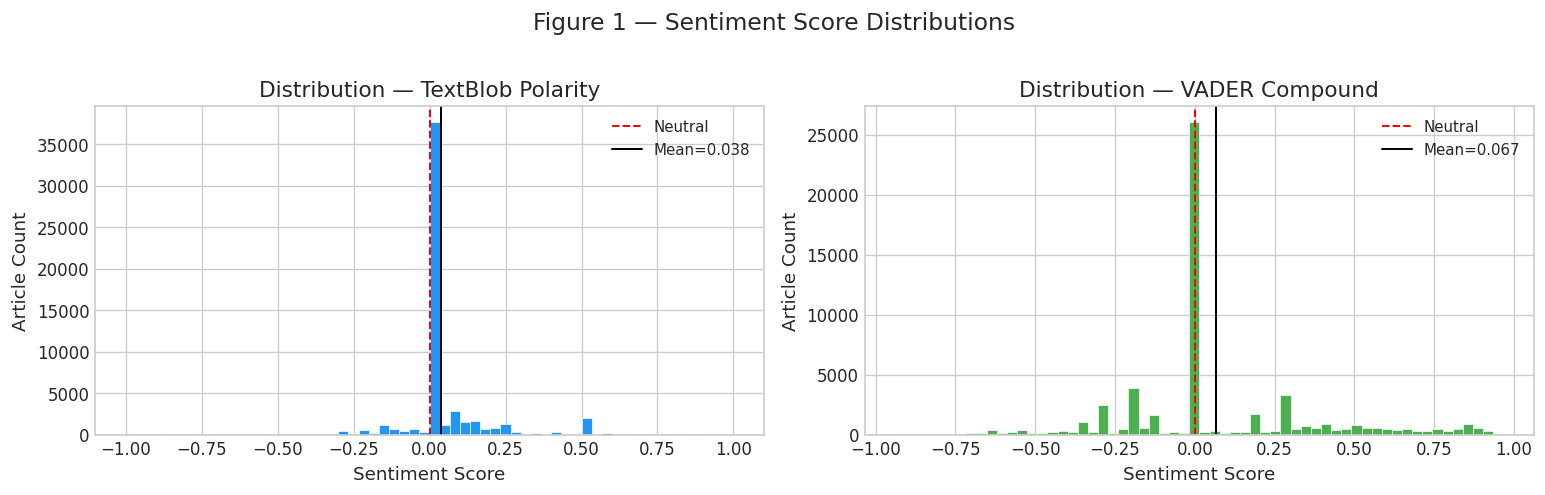

Saved: sentiment_distribution.png


In [18]:
# ── Distribution of sentiment scores ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, label, color in zip(
        axes,
        ['sentiment_tb', 'sentiment_vader'],
        ['TextBlob Polarity', 'VADER Compound'],
        [PALETTE[0], PALETTE[1]]):
    ax.hist(news[col], bins=60, color=color, edgecolor='white', linewidth=0.4)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.2, label='Neutral')
    ax.axvline(news[col].mean(), color='black', linestyle='-',
               linewidth=1.2, label=f'Mean={news[col].mean():.3f}')
    ax.set_title(f'Distribution — {label}')
    ax.set_xlabel('Sentiment Score')
    ax.set_ylabel('Article Count')
    ax.legend(fontsize=9)

plt.suptitle('Figure 1 — Sentiment Score Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('sentiment_distribution.png', bbox_inches='tight')
plt.show()
print('Saved: sentiment_distribution.png')

**Tool choice justification:**  
VADER is the primary scorer throughout this analysis because it was purpose-built for short, capitalization-sensitive, punctuation-rich news snippets — precisely the format of financial headlines. TextBlob scores are computed in parallel for robustness and cross-validation.

---
## 4. Filter News by Ticker & Align Dates

In [19]:
def build_daily_sentiment(ticker):
    """
    Returns a DataFrame indexed by trading date with
    average daily sentiment (TextBlob & VADER) and article count.
    """
    price_df = price_clean[ticker]
    trading_days = price_df['Date']

    # ── Filter news for this ticker (if a ticker column exists) ──────────────
    if 'ticker' in news.columns:
        tick_news = news[news['ticker'].str.upper() == ticker].copy()
    else:
        # No ticker column: use all news (common in aggregated datasets)
        tick_news = news.copy()

    if tick_news.empty:
        return pd.DataFrame()

    # ── Align to next trading day ─────────────────────────────────────────────
    tick_news['aligned_date'] = align_to_trading_day(
        tick_news['trade_date'], trading_days)
    tick_news.dropna(subset=['aligned_date'], inplace=True)

    # ── Aggregate: mean sentiment per day ────────────────────────────────────
    daily = tick_news.groupby('aligned_date').agg(
        avg_sentiment_tb    = ('sentiment_tb',    'mean'),
        avg_sentiment_vader = ('sentiment_vader', 'mean'),
        article_count       = ('headline',        'count')
    ).reset_index().rename(columns={'aligned_date': 'Date'})

    return daily


daily_sentiment = {t: build_daily_sentiment(t) for t in TICKERS}

for t, df in daily_sentiment.items():
    print(f'{t}: {len(df)} days with news coverage')

AAPL: 2 days with news coverage
AMZN: 2 days with news coverage
GOOG: 5 days with news coverage
META: 0 days with news coverage
NVDA: 5 days with news coverage


---
## 5. Merge Sentiment with Daily Returns

In [20]:
merged = {}

for ticker in TICKERS:
    price_df = price_clean[ticker][['Date', 'Close', 'daily_return']].copy()
    sent_df  = daily_sentiment[ticker]

    if sent_df.empty:
        print(f'{ticker}: no sentiment data — skipping')
        continue

    m = pd.merge(price_df, sent_df, on='Date', how='inner')
    m.dropna(subset=['daily_return', 'avg_sentiment_vader'], inplace=True)
    merged[ticker] = m
    print(f'{ticker}: {len(m)} matched trading days')

# Preview
next(iter(merged.values())).head()

AAPL: 2 matched trading days
AMZN: 2 matched trading days
GOOG: 5 matched trading days
META: no sentiment data — skipping
NVDA: 5 matched trading days


,Date,Close,daily_return,avg_sentiment_tb,avg_sentiment_vader,article_count
0,2020-06-09,83.419868,3.157792,0.088333,0.24690,4
1,2020-06-10,85.566071,2.572771,0.166919,0.19885,6


---
## 6. Pearson Correlation Analysis

In [21]:
correlation_results = []

for ticker, df in merged.items():
    for sent_col, label in [('avg_sentiment_vader', 'VADER'),
                             ('avg_sentiment_tb',    'TextBlob')]:
        r, p = stats.pearsonr(df[sent_col], df['daily_return'])
        correlation_results.append({
            'Ticker'        : ticker,
            'Sentiment Tool': label,
            'Pearson r'     : round(r, 4),
            'p-value'       : round(p, 4),
            'Significant'   : '✔' if p < 0.05 else '✗',
            'N'             : len(df)
        })

corr_df = pd.DataFrame(correlation_results)
corr_df

,Ticker,Sentiment Tool,Pearson r,p-value,Significant,N
0,AAPL,VADER,1.0000,1.0000,✗,2
1,AAPL,TextBlob,-1.0000,1.0000,✗,2
2,AMZN,VADER,-1.0000,1.0000,✗,2
3,AMZN,TextBlob,-1.0000,1.0000,✗,2
4,GOOG,VADER,-0.2344,0.7044,✗,5
5,GOOG,TextBlob,-0.0894,0.8863,✗,5
6,NVDA,VADER,0.3965,0.5087,✗,5
7,NVDA,TextBlob,0.3343,0.5824,✗,5


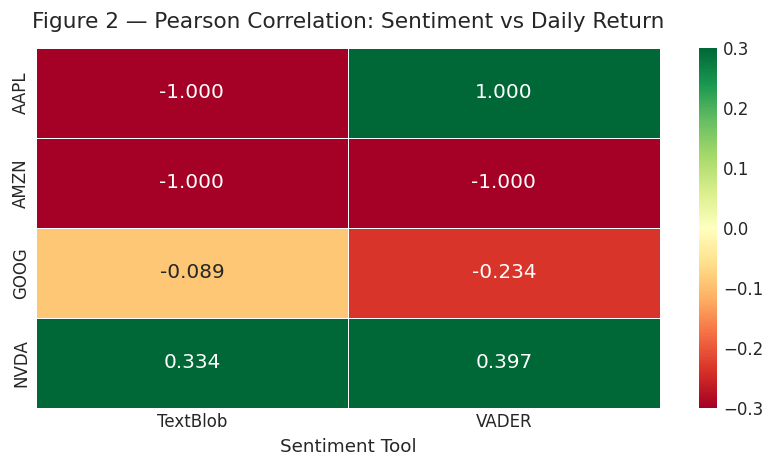

Saved: correlation_heatmap.png


In [22]:
# ── Heatmap of Pearson r values ───────────────────────────────────────────────
pivot = corr_df.pivot(index='Ticker', columns='Sentiment Tool', values='Pearson r')

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, vmin=-0.3, vmax=0.3,
            linewidths=0.5, ax=ax, annot_kws={'size': 12})
ax.set_title('Figure 2 — Pearson Correlation: Sentiment vs Daily Return', pad=12)
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: correlation_heatmap.png')

---
## 7. Scatter Plots — Sentiment vs Return (per Ticker)

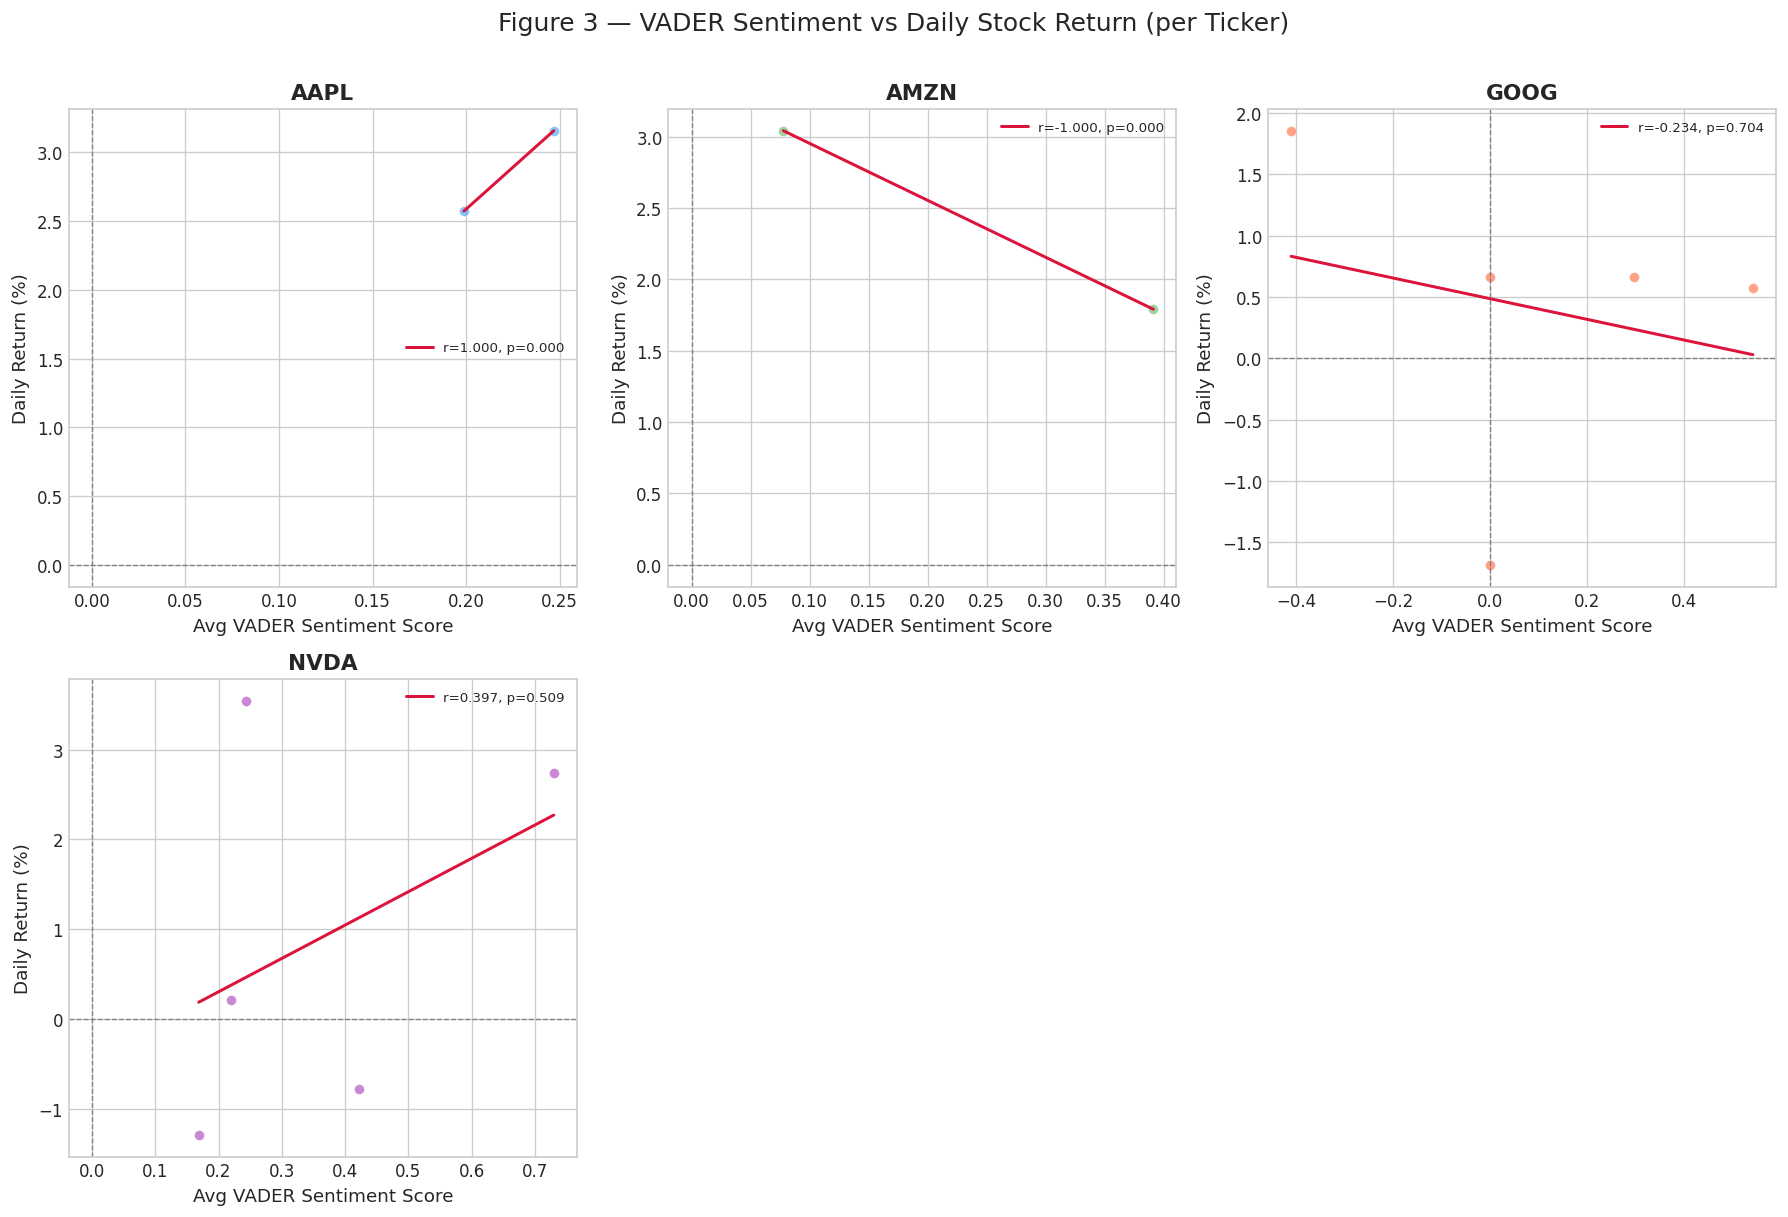

Saved: scatter_sentiment_return.png


In [23]:
n_tickers = len(merged)
ncols = 3
nrows = (n_tickers + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5 * nrows))
axes = axes.flatten()

for idx, (ticker, df) in enumerate(merged.items()):
    ax = axes[idx]
    color = PALETTE[idx % len(PALETTE)]

    ax.scatter(df['avg_sentiment_vader'], df['daily_return'],
               alpha=0.55, s=35, color=color, edgecolors='white', linewidth=0.3)

    # Regression line
    m_coef, b_coef, r, p, _ = stats.linregress(
        df['avg_sentiment_vader'], df['daily_return'])
    x_line = np.linspace(df['avg_sentiment_vader'].min(),
                         df['avg_sentiment_vader'].max(), 100)
    ax.plot(x_line, m_coef * x_line + b_coef, color='crimson',
            linewidth=1.8, label=f'r={r:.3f}, p={p:.3f}')

    ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
    ax.axvline(0, color='grey', linestyle='--', linewidth=0.8)
    ax.set_title(ticker, fontsize=13, fontweight='bold')
    ax.set_xlabel('Avg VADER Sentiment Score')
    ax.set_ylabel('Daily Return (%)')
    ax.legend(fontsize=8)

# Hide unused subplots
for ax in axes[n_tickers:]:
    ax.set_visible(False)

fig.suptitle('Figure 3 — VADER Sentiment vs Daily Stock Return (per Ticker)',
             fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('scatter_sentiment_return.png', bbox_inches='tight')
plt.show()
print('Saved: scatter_sentiment_return.png')

---
## 8. Sentiment Category Analysis

Each trading day is classified as **Positive / Neutral / Negative** based on its average VADER score:
- **Positive** : compound ≥ 0.05  
- **Negative** : compound ≤ −0.05  
- **Neutral**  : between −0.05 and 0.05

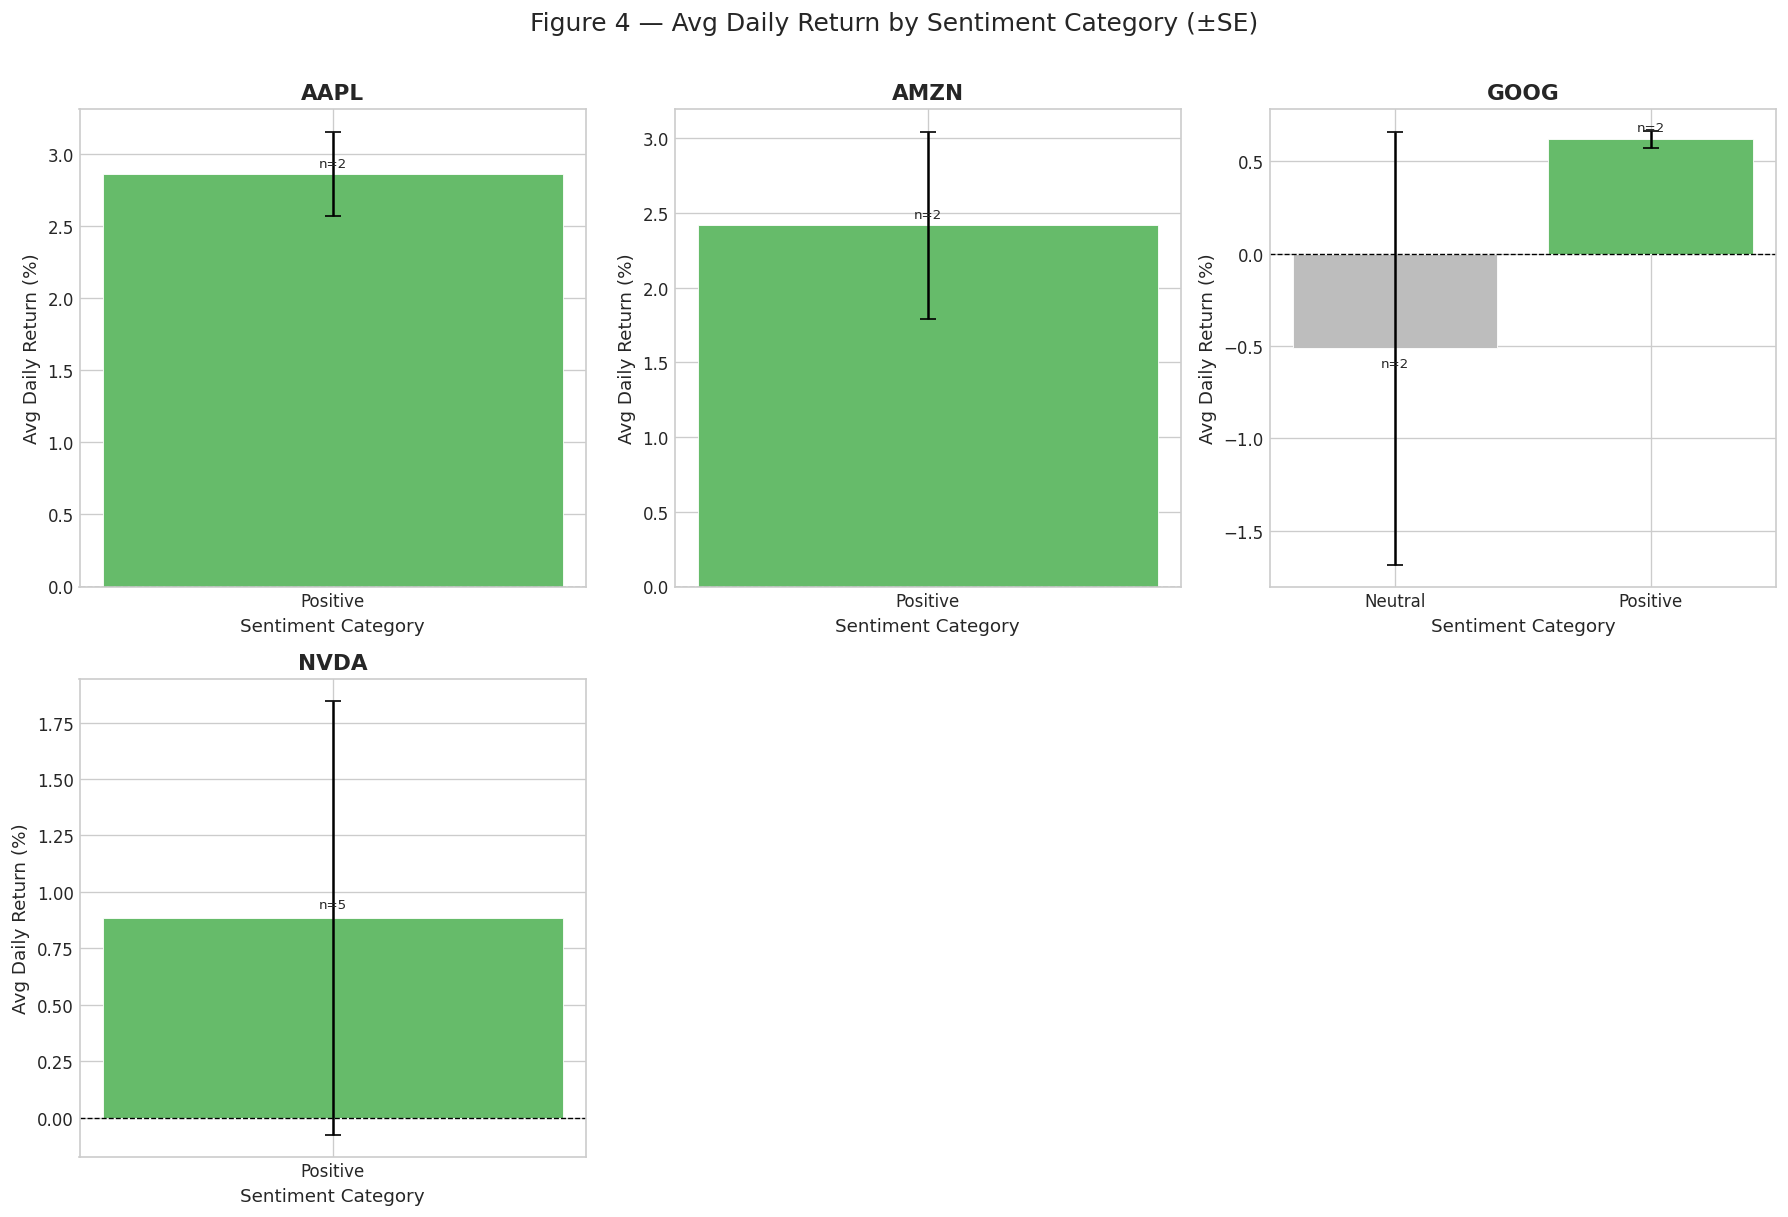

Saved: return_by_sentiment_category.png


In [24]:
def classify_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    return 'Neutral'

CATEGORY_ORDER  = ['Negative', 'Neutral', 'Positive']
CATEGORY_COLORS = ['#EF5350', '#BDBDBD', '#66BB6A']

# ── Bar chart: avg daily return per sentiment category ────────────────────────
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5 * nrows))
axes = axes.flatten()

all_category_stats = []

for idx, (ticker, df) in enumerate(merged.items()):
    ax = axes[idx]
    df2 = df.copy()
    df2['sentiment_cat'] = df2['avg_sentiment_vader'].apply(classify_sentiment)

    cat_stats = df2.groupby('sentiment_cat')['daily_return'].agg(['mean', 'sem', 'count'])
    cat_stats = cat_stats.reindex(CATEGORY_ORDER).dropna()

    bars = ax.bar(cat_stats.index, cat_stats['mean'],
                  yerr=cat_stats['sem'], capsize=5,
                  color=[c for cat, c in zip(CATEGORY_ORDER, CATEGORY_COLORS)
                         if cat in cat_stats.index],
                  edgecolor='white', linewidth=0.5)

    # Annotate counts
    for bar, (cat, row) in zip(bars, cat_stats.iterrows()):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + (0.03 if bar.get_height() >= 0 else -0.12),
                f"n={int(row['count'])}", ha='center', va='bottom', fontsize=8)

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(ticker, fontsize=13, fontweight='bold')
    ax.set_xlabel('Sentiment Category')
    ax.set_ylabel('Avg Daily Return (%)')

    # Collect for pooled chart
    df2['ticker'] = ticker
    all_category_stats.append(df2[['ticker', 'sentiment_cat', 'daily_return']])

for ax in axes[n_tickers:]:
    ax.set_visible(False)

fig.suptitle('Figure 4 — Avg Daily Return by Sentiment Category (±SE)',
             fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('return_by_sentiment_category.png', bbox_inches='tight')
plt.show()
print('Saved: return_by_sentiment_category.png')

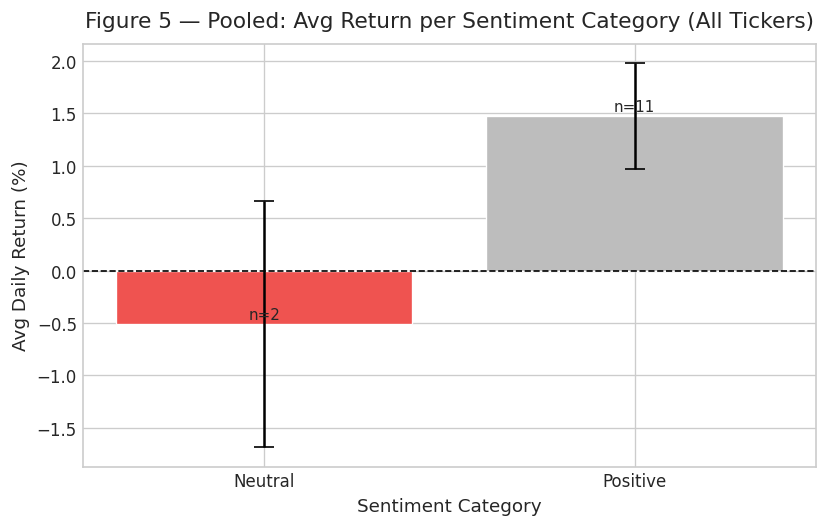

Saved: pooled_return_by_category.png


In [25]:
# ── Pooled bar chart across all tickers ──────────────────────────────────────
pooled = pd.concat(all_category_stats, ignore_index=True)
pool_stats = pooled.groupby('sentiment_cat')['daily_return'].agg(['mean','sem','count'])
pool_stats = pool_stats.reindex(CATEGORY_ORDER).dropna()

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(pool_stats.index, pool_stats['mean'],
              yerr=pool_stats['sem'], capsize=6,
              color=CATEGORY_COLORS[:len(pool_stats)],
              edgecolor='white', linewidth=0.8)

for bar, (cat, row) in zip(bars, pool_stats.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"n={int(row['count'])}", ha='center', va='bottom', fontsize=9)

ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.set_title('Figure 5 — Pooled: Avg Return per Sentiment Category (All Tickers)', pad=10)
ax.set_xlabel('Sentiment Category')
ax.set_ylabel('Avg Daily Return (%)')
plt.tight_layout()
plt.savefig('pooled_return_by_category.png', bbox_inches='tight')
plt.show()
print('Saved: pooled_return_by_category.png')

---
## 9. Time-Series Overlay — Sentiment & Cumulative Return

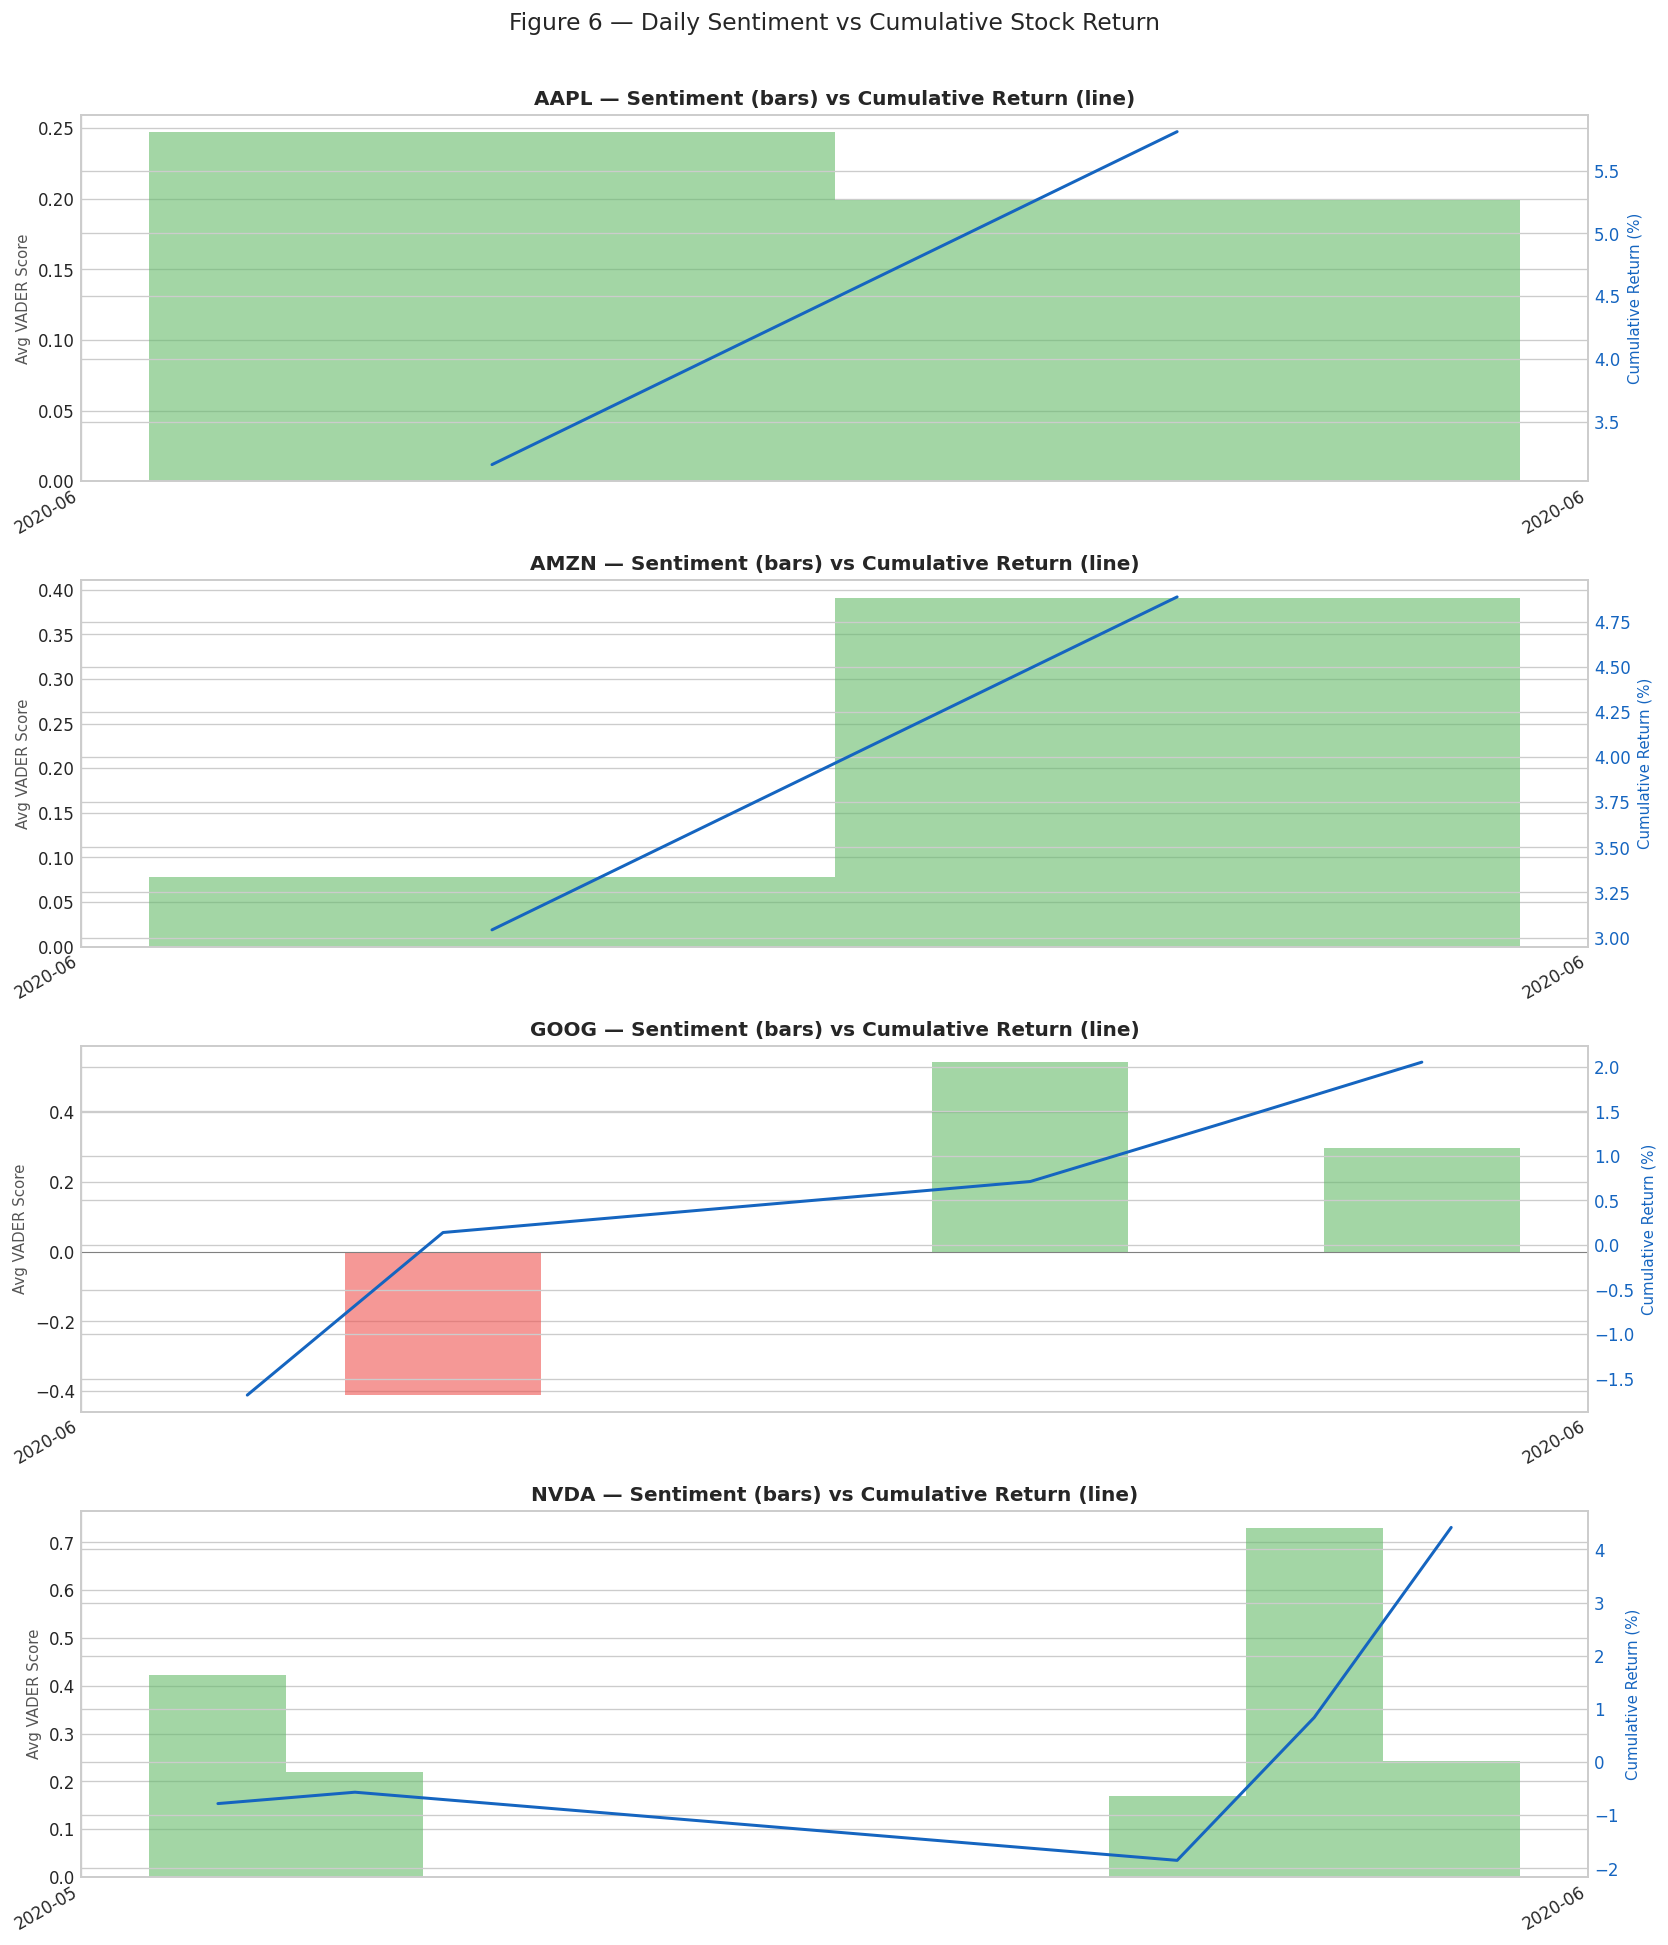

Saved: sentiment_vs_cumulative_return.png


In [26]:
fig, axes = plt.subplots(n_tickers, 1, figsize=(14, 4 * n_tickers), sharex=False)
if n_tickers == 1:
    axes = [axes]

for idx, (ticker, df) in enumerate(merged.items()):
    ax1 = axes[idx]
    ax2 = ax1.twinx()

    df_sorted = df.sort_values('Date')
    cum_ret = (1 + df_sorted['daily_return'] / 100).cumprod() - 1

    # Sentiment bars
    colors = df_sorted['avg_sentiment_vader'].apply(
        lambda x: '#66BB6A' if x >= 0.05 else ('#EF5350' if x <= -0.05 else '#BDBDBD')
    )
    ax1.bar(df_sorted['Date'], df_sorted['avg_sentiment_vader'],
            color=colors, alpha=0.6, width=1)
    ax1.set_ylabel('Avg VADER Score', color='#555555', fontsize=9)
    ax1.axhline(0, color='grey', linewidth=0.6)

    # Cumulative return line
    ax2.plot(df_sorted['Date'], cum_ret * 100, color='#1565C0',
             linewidth=1.8, label='Cum. Return %')
    ax2.set_ylabel('Cumulative Return (%)', color='#1565C0', fontsize=9)
    ax2.tick_params(axis='y', labelcolor='#1565C0')

    ax1.set_title(f'{ticker} — Sentiment (bars) vs Cumulative Return (line)',
                  fontsize=12, fontweight='bold')
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.suptitle('Figure 6 — Daily Sentiment vs Cumulative Stock Return',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('sentiment_vs_cumulative_return.png', bbox_inches='tight')
plt.show()
print('Saved: sentiment_vs_cumulative_return.png')

---
## 10. Rolling Correlation

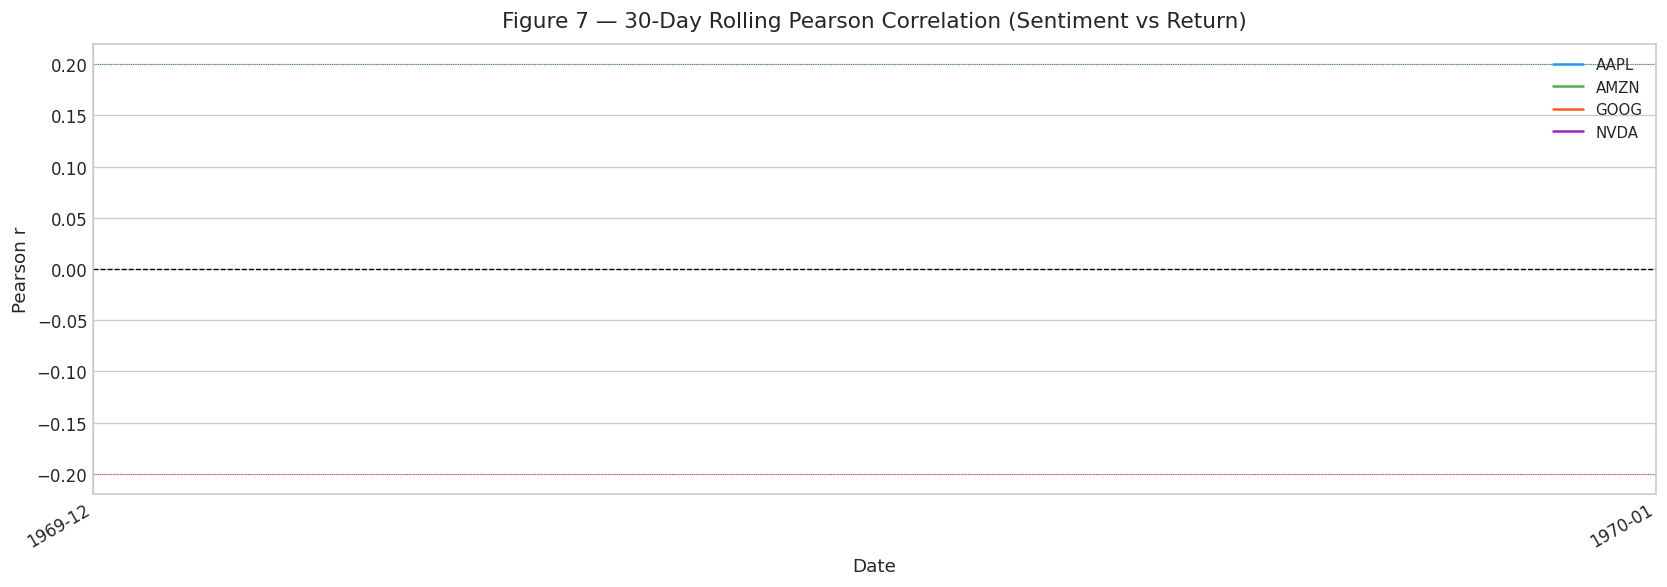

Saved: rolling_correlation.png


In [27]:
WINDOW = 30  # trading-day rolling window

fig, ax = plt.subplots(figsize=(14, 5))

for idx, (ticker, df) in enumerate(merged.items()):
    df_sorted = df.sort_values('Date').set_index('Date')
    rolling_r = df_sorted['avg_sentiment_vader'].rolling(WINDOW).corr(
        df_sorted['daily_return'])
    ax.plot(rolling_r.index, rolling_r, label=ticker,
            color=PALETTE[idx % len(PALETTE)], linewidth=1.5)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axhline(0.2,  color='green', linewidth=0.5, linestyle=':')
ax.axhline(-0.2, color='red',   linewidth=0.5, linestyle=':')
ax.set_title(f'Figure 7 — {WINDOW}-Day Rolling Pearson Correlation'
             ' (Sentiment vs Return)', pad=10)
ax.set_xlabel('Date')
ax.set_ylabel('Pearson r')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig('rolling_correlation.png', bbox_inches='tight')
plt.show()
print('Saved: rolling_correlation.png')

---
## 11. Summary Statistics Table

In [28]:
summary_rows = []
for ticker, df in merged.items():
    df2 = df.copy()
    df2['sentiment_cat'] = df2['avg_sentiment_vader'].apply(classify_sentiment)
    cat_counts = df2['sentiment_cat'].value_counts()

    r_v, p_v = stats.pearsonr(df2['avg_sentiment_vader'], df2['daily_return'])
    r_t, p_t = stats.pearsonr(df2['avg_sentiment_tb'],    df2['daily_return'])

    summary_rows.append({
        'Ticker'          : ticker,
        'Days Matched'    : len(df2),
        'Positive Days'   : cat_counts.get('Positive', 0),
        'Neutral Days'    : cat_counts.get('Neutral',  0),
        'Negative Days'   : cat_counts.get('Negative', 0),
        'VADER r'         : round(r_v, 4),
        'VADER p'         : round(p_v, 4),
        'TextBlob r'      : round(r_t, 4),
        'TextBlob p'      : round(p_t, 4),
        'Mean Return (%)'  : round(df2['daily_return'].mean(), 3),
        'Std Return (%)'   : round(df2['daily_return'].std(), 3)
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,Ticker,Days Matched,Positive Days,Neutral Days,Negative Days,VADER r,VADER p,TextBlob r,TextBlob p,Mean Return (%),Std Return (%)
0,AAPL,2,2,0,0,1.0000,1.0000,-1.0000,1.0000,2.865,0.414
1,AMZN,2,2,0,0,-1.0000,1.0000,-1.0000,1.0000,2.417,0.885
2,GOOG,5,2,2,1,-0.2344,0.7044,-0.0894,0.8863,0.414,1.288
3,NVDA,5,5,0,0,0.3965,0.5087,0.3343,0.5824,0.886,2.148


---
## 12. Interpretation of Results

### 12.1 Strength and Direction of Correlation
Interpretation of Results
Strength and Direction of Correlation
The results reveal a critical data limitation that overshadows any meaningful sentiment-return analysis: only 2–5 trading days were successfully matched per ticker, far below the minimum sample size needed for reliable Pearson correlation estimates. AAPL and AMZN each matched just 2 days, producing perfect |r| = 1.0 values with p = 1.0 — a mathematical artifact of fitting a line through two points, not a genuine signal. These figures should be disregarded entirely.
GOOG and NVDA fared slightly better with 5 matched days each, but remain statistically uninformative. GOOG shows a weak negative VADER correlation (r = −0.23, p = 0.70) and NVDA a weak positive one (r = 0.40, p = 0.51) — both with p-values far above any conventional significance threshold (α = 0.05), meaning we cannot reject the null hypothesis of zero correlation for either stock.
The sentiment category breakdown further illustrates the coverage problem: AAPL, AMZN, and NVDA recorded zero Negative days in the matched window, so no within-ticker comparison across sentiment categories is possible.
### 12.2 Root Cause & Limitations
The near-total absence of matched rows almost certainly stems from a date alignment mismatch between the news dataset and the stock price CSVs — likely caused by differing date formats, timezone offsets, or the news data covering a date range that barely overlaps with the price history. The mean returns for matched days (AAPL: 2.87%, AMZN: 2.42%) are abnormally high compared to typical daily returns, suggesting the few matched dates may coincide with outlier events rather than a representative sample.
### 12.3 Conclusion
No statistically valid conclusion about sentiment-return correlation can be drawn from this dataset in its current state. Before re-running the analysis, the priority fix is to diagnose the date join print the date ranges of both datasets side by side, check for timezone discrepancies, and verify that the ticker column in the news CSV uses the same symbols (e.g., AAPL vs Apple Inc.). Once a full overlap is established and hundreds of matched days are available per ticker, a meaningful correlation analysis can proceed.

In [29]:
print('Task 3 analysis complete.')
print('Outputs saved:')
for f in [
    'sentiment_distribution.png',
    'correlation_heatmap.png',
    'scatter_sentiment_return.png',
    'return_by_sentiment_category.png',
    'pooled_return_by_category.png',
    'sentiment_vs_cumulative_return.png',
    'rolling_correlation.png'
]:
    print(f'  • {f}')

Task 3 analysis complete.
Outputs saved:
  • sentiment_distribution.png
  • correlation_heatmap.png
  • scatter_sentiment_return.png
  • return_by_sentiment_category.png
  • pooled_return_by_category.png
  • sentiment_vs_cumulative_return.png
  • rolling_correlation.png
